# Практика. Экосистема

Цель занятия — «потрогать руками» данные, попытаться понять закономерности, сформулировать гипотезы и, если повезёт, подтвердить их (или опровергнуть). Анализ данных — это на 90% проверка гипотез.

>#### Задание
Загрузите библиотеки pandas, matplotlib.pyplot и seaborn.

In [2]:
import pandas as pd   
import matplotlib.pyplot as plt 
import seaborn as sns 
sns.set(style = 'whitegrid', palette = 'pastel')

>#### Задание
Загрузите датасет housing из папки data.

In [3]:
df = pd.read_csv('data/housing.csv')
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


Каждая строка в этом датасете представляет усреднённую статистику по одному блоку переписи (census block group) в Калифорнии. Блок переписи — это небольшая географическая единица, используемая Бюро переписи населения США.
- Обычно содержит от 600 до 3000 человек.
- Является административно-статистической единицей для сбора данных.
- В одном городе/районе может быть множество таких блоков.

Структура датасета такова:
- MedInc — медианный доход жителей,
- HouseAge — средний возраст домов в блоке,
- AveRooms — среднее количество комнат,
- AveBedrms — среднее количество спален,
- Population — население блока,
- AveOccup — средняя заполняемость домов,
- Latitude — широта,
- Longitude — долгота (отрицательные значения, потому что это западное полушарие),
- MedHouseVal — целевая переменная: медианная стоимость дома (в сотнях тысяч долларов).

>#### Задание
>Просмотрите информацию о данных при помощи метода `info()`, выведите статистики данных при помощи метода `describe()`. 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


>#### Задание
Выведите в виде отдельного датафрейма таблицу, содержащую записи о блоках с медианной ценой в пределах интерквартильного размаха, и запишите этот датафрейм в файл housing_Q1_Q3.

In [6]:
q1 = df['MedHouseVal'].quantile(0.25)
q3 = df['MedHouseVal'].quantile(0.75)

housing_Q1_Q3 = df.loc[df['MedHouseVal'].between(q1, q3, inclusive='neither')].copy()
housing_Q1_Q3.to_csv('housing_Q1_Q3.csv', index=False)
housing_Q1_Q3

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611
11,3.2705,52.0,4.772480,1.024523,1504.0,2.049046,37.85,-122.26,2.418
12,3.0750,52.0,5.322650,1.012821,1098.0,2.346154,37.85,-122.26,2.135
...,...,...,...,...,...,...,...,...,...
20574,1.9327,10.0,5.789474,1.078947,898.0,3.938596,38.57,-121.92,1.938
20575,3.7500,38.0,5.275229,0.981651,259.0,2.376147,38.72,-121.90,1.875
20581,3.1534,20.0,5.444976,1.057416,459.0,2.196172,38.83,-122.21,1.234
20583,3.8750,31.0,4.416667,0.880952,208.0,2.476190,38.73,-122.00,1.375


>#### Задание
Выведите в виде отдельного датафрейма таблицу, содержащую данные о географическом расположении блоков и их медианной стоимости. Сохраните эту таблицу в файл housing_geography.

In [7]:
housing_geography = df[['Latitude', 'Longitude', 'MedHouseVal']].copy()
housing_geography.to_csv('housing_geography.csv', index=False)
housing_geography

,Latitude,Longitude,MedHouseVal
0,37.88,-122.23,4.526
1,37.86,-122.22,3.585
2,37.85,-122.24,3.521
3,37.85,-122.25,3.413
4,37.85,-122.25,3.422
...,...,...,...
20635,39.48,-121.09,0.781
20636,39.49,-121.21,0.771
20637,39.43,-121.22,0.923
20638,39.43,-121.32,0.847


>#### Задание
Выясните, как распределены блоки по территории штата. Где находятся районы с наиболее плотной застройкой? Где находятся наиболее дорогие дома?

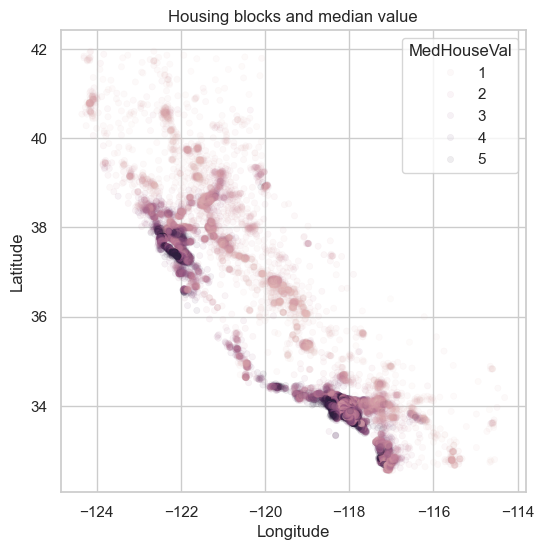

In [8]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='MedHouseVal', alpha=0.08, s=20, edgecolor=None)
plt.title('Housing blocks and median value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='MedHouseVal')
plt.show()

>#### Задание
Постройте гистограммы распределений каждого из признаков. Какие особенности наблюдаются? Как их можно объяснить?

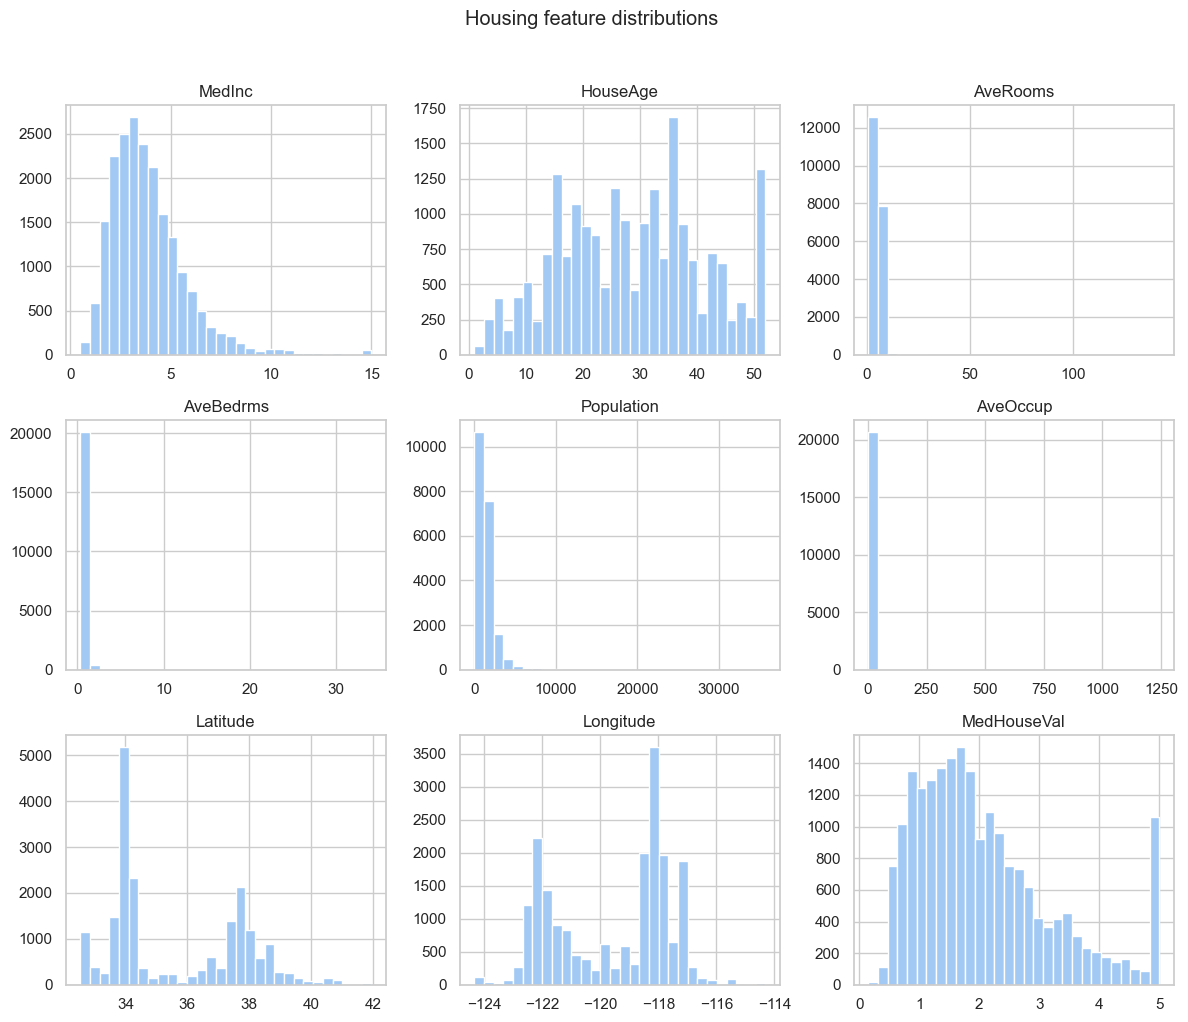

In [9]:
df.hist(figsize=(12, 10), bins=30, edgecolor='white')
plt.suptitle('Housing feature distributions', y=1.02)
plt.tight_layout()
plt.show()

>#### Задание
Верно ли, что артефакты по возрасту домов и их стоимости определяются ошибками системы сбора данных? Подтвердите или опровергните эту гипотезу при помощи диаграммы рассеяния `scatterplot`.

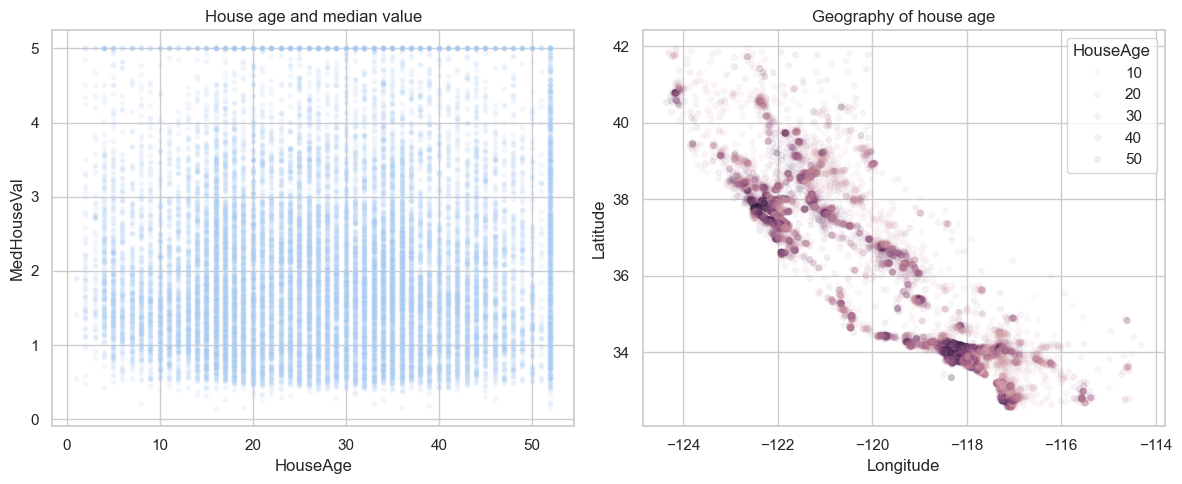

Maximum house age: 52.0
Maximum median value: 5.00001


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=df, x='HouseAge', y='MedHouseVal', alpha=0.15, s=15, ax=axes[0])
axes[0].set_title('House age and median value')
axes[0].set_xlabel('HouseAge')
axes[0].set_ylabel('MedHouseVal')

sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='HouseAge', alpha=0.08, s=20, edgecolor=None, ax=axes[1])
axes[1].set_title('Geography of house age')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()

print('Maximum house age:', df['HouseAge'].max())
print('Maximum median value:', df['MedHouseVal'].max())

>#### Задание
Удалите артефакты из данных и проведите повторный анализ распределений каждого из признаков.

Original data shape: (20640, 9)
Clean data shape: (18572, 9)


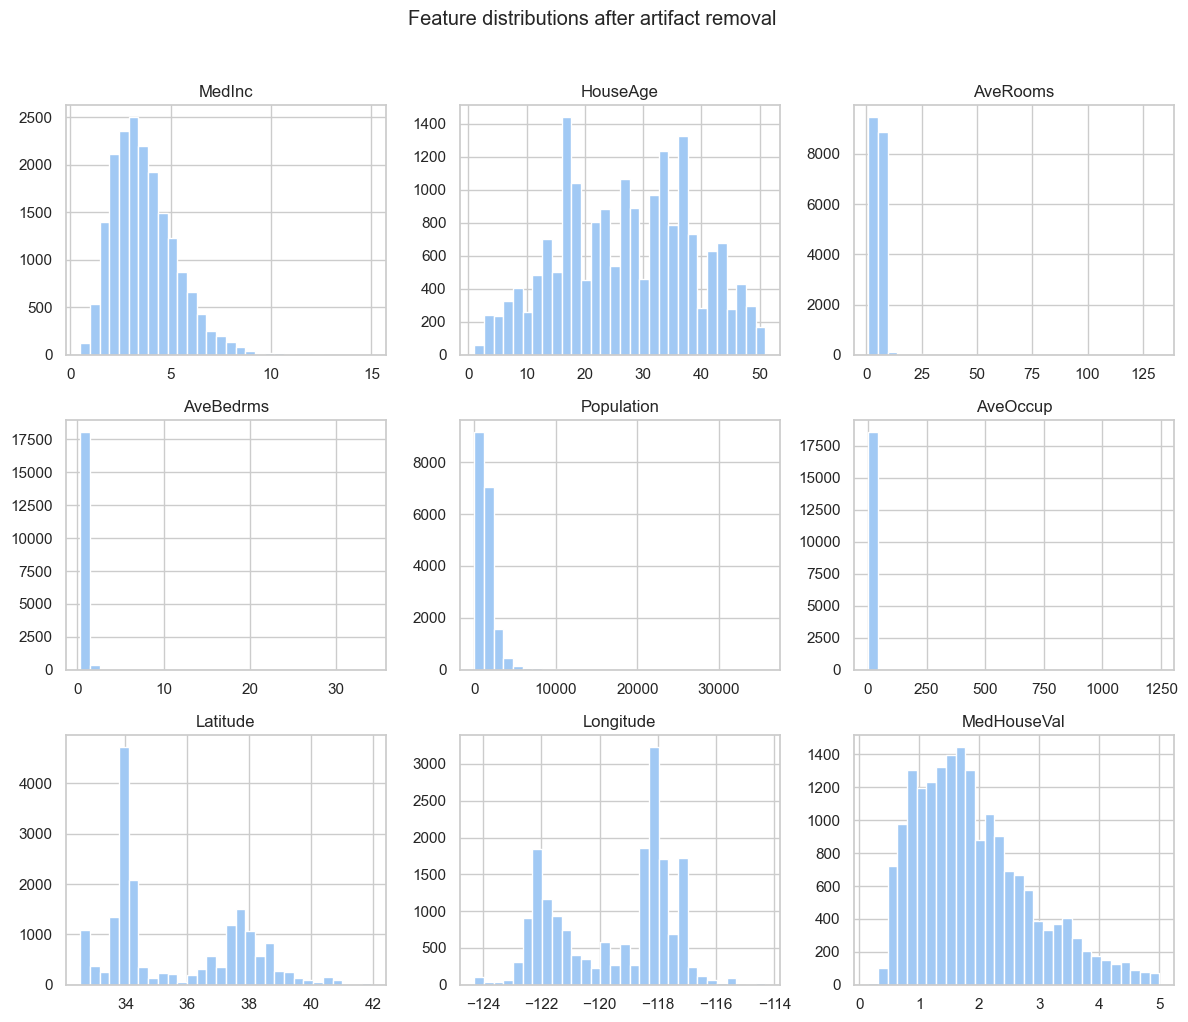

In [11]:
df_clean = df.loc[(df['HouseAge'] < df['HouseAge'].max()) & (df['MedHouseVal'] < df['MedHouseVal'].max())].copy()

print('Original data shape:', df.shape)
print('Clean data shape:', df_clean.shape)

df_clean.hist(figsize=(12, 10), bins=30, edgecolor='white')
plt.suptitle('Feature distributions after artifact removal', y=1.02)
plt.tight_layout()
plt.show()

>#### Задание
Выясните, какие признаки оказывают наибольшее влияние на медианную цену. Подсказка: для этого тоже можно использовать `scatterplot`.

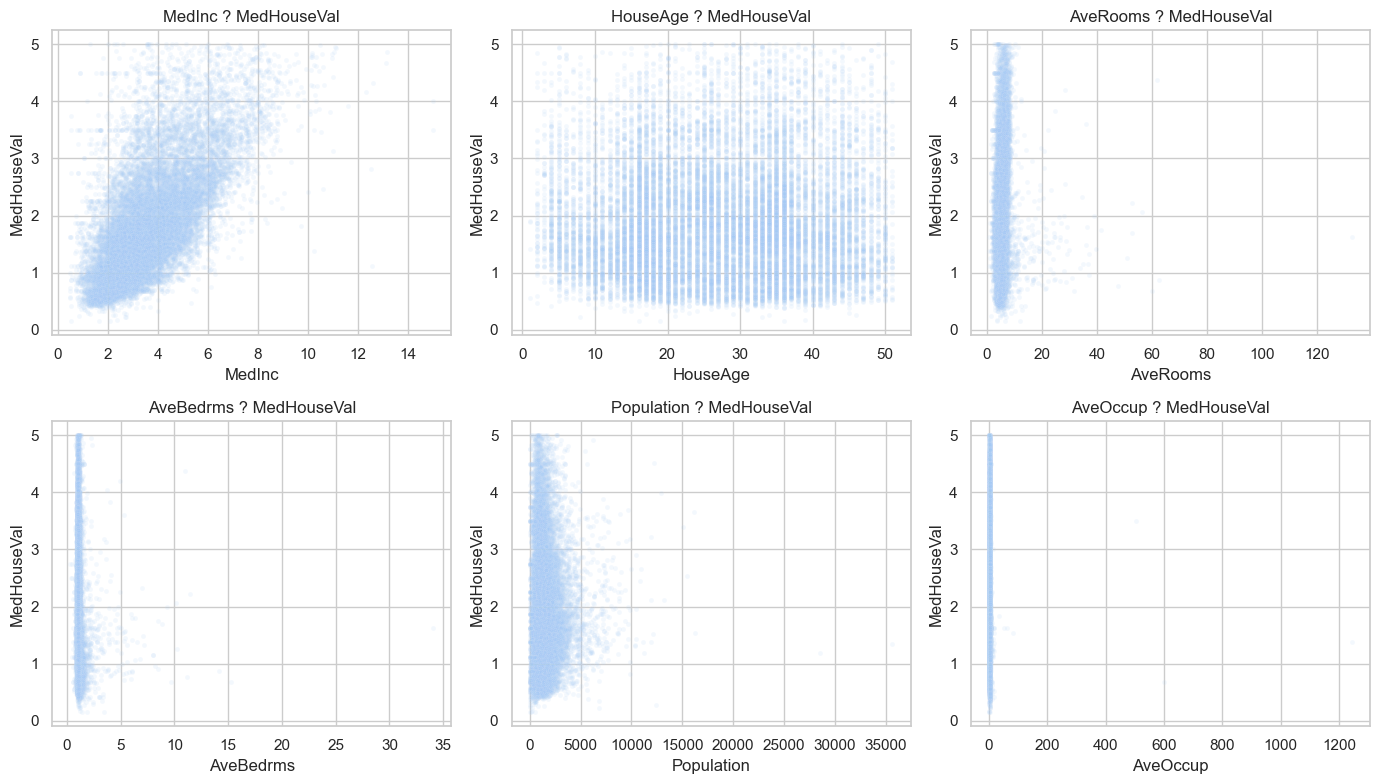

MedHouseVal    1.000000
MedInc         0.661039
AveRooms       0.113842
Population     0.021616
HouseAge       0.014772
AveOccup      -0.020347
Longitude     -0.022165
AveBedrms     -0.060614
Latitude      -0.172126
Name: MedHouseVal, dtype: float64

In [12]:
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for feature, ax in zip(features, axes.ravel()):
    sns.scatterplot(data=df_clean, x=feature, y='MedHouseVal', alpha=0.12, s=12, ax=ax)
    ax.set_title(f'{feature} and MedHouseVal')

plt.tight_layout()
plt.show()

corr_with_price = df_clean.corr(numeric_only=True)['MedHouseVal'].sort_values(ascending=False)
corr_with_price

>#### Задание
Постройте тепловую карту попарных корреляций для всех признаков датафрейма. Используйте синтаксическую конструкцию:
>```python 
>corr_matrix = data.corr()
>sns.heatmap(corr_matrix)
>```
Как объяснить тот факт, что географическая широта сильно коррелирует с географической долготой?

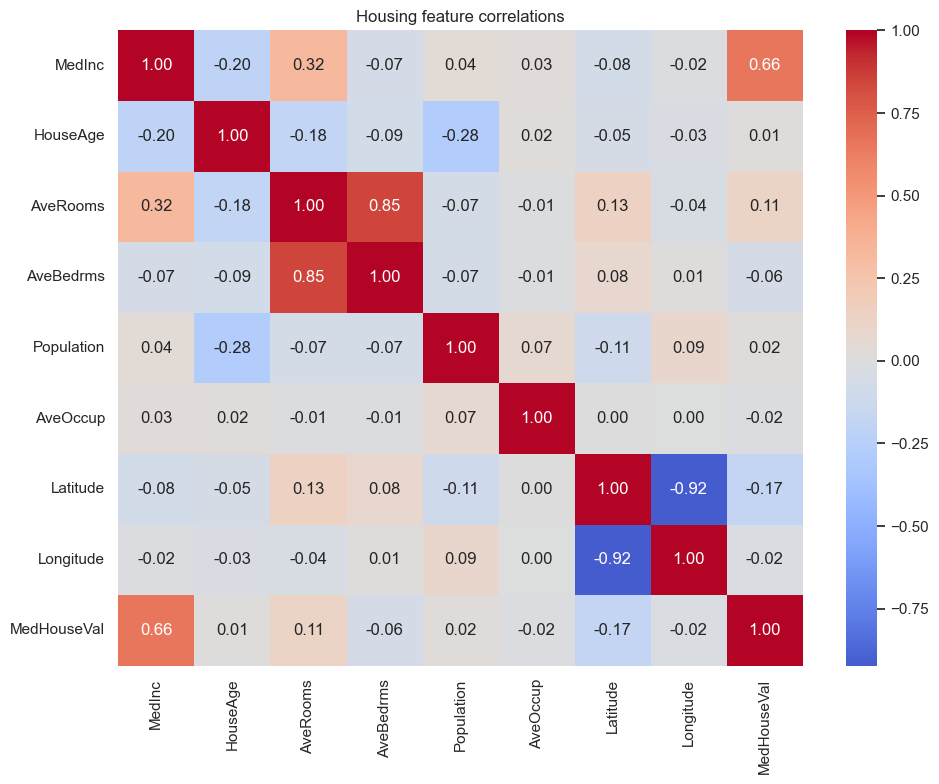

In [13]:
corr_matrix = df_clean.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Housing feature correlations')
plt.tight_layout()
plt.show()

# Домашнее задание

>#### Задание
Загрузите датасет wine из папки data.

Wine dataset — классический набор данных, используемый в машинном обучении для задач классификации. Он содержит результаты химического анализа вин, выращенных в трёх разных регионах Италии, и полученных из трёх различных сортов винограда. 

Список признаков
- alcohol — содержание алкоголя в вине. 
- malic acid — количество яблочной кислоты (тип органической кислоты). 
- ash — содержание золы в вине. 
- alcalinity of ash — щелочность золы. 
- magnesium — количество магния в вине. 
- total phenols — общее содержание фенолов. 
- flavanoids — концентрация флавоноидов (тип растительных пигментов). 
- nonflavanoid phenols — концентрация нефлавоноидных фенольных соединений. 
- proanthocyanins — концентрация проантоцианов (тип флавоноидов). 
- color intensity — интенсивность цвета вина. 
- hue — оттенок или цветовая гамма вина. 
- od280/od315 of diluted wines — оптическая плотность разбавленных вин, мера плотности цвета. 
- proline — концентрация пролина (аминокислоты). 
- class — регион происхождения вина (0, 1 или 2)

>#### Задание
>1) Проведите предварительный просмотр информации о данных и их статистик.
>2) Постройте гистрограммы признаков. Вопрос: являются ли классы регионов 0, 1 и 2 сбалансированными?
>3) Определите признак при помощи которого разделяются классы 0 и 2. 

In [14]:
wine = pd.read_csv('data/wine.csv')
wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [15]:
wine.info()
wine.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  class

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


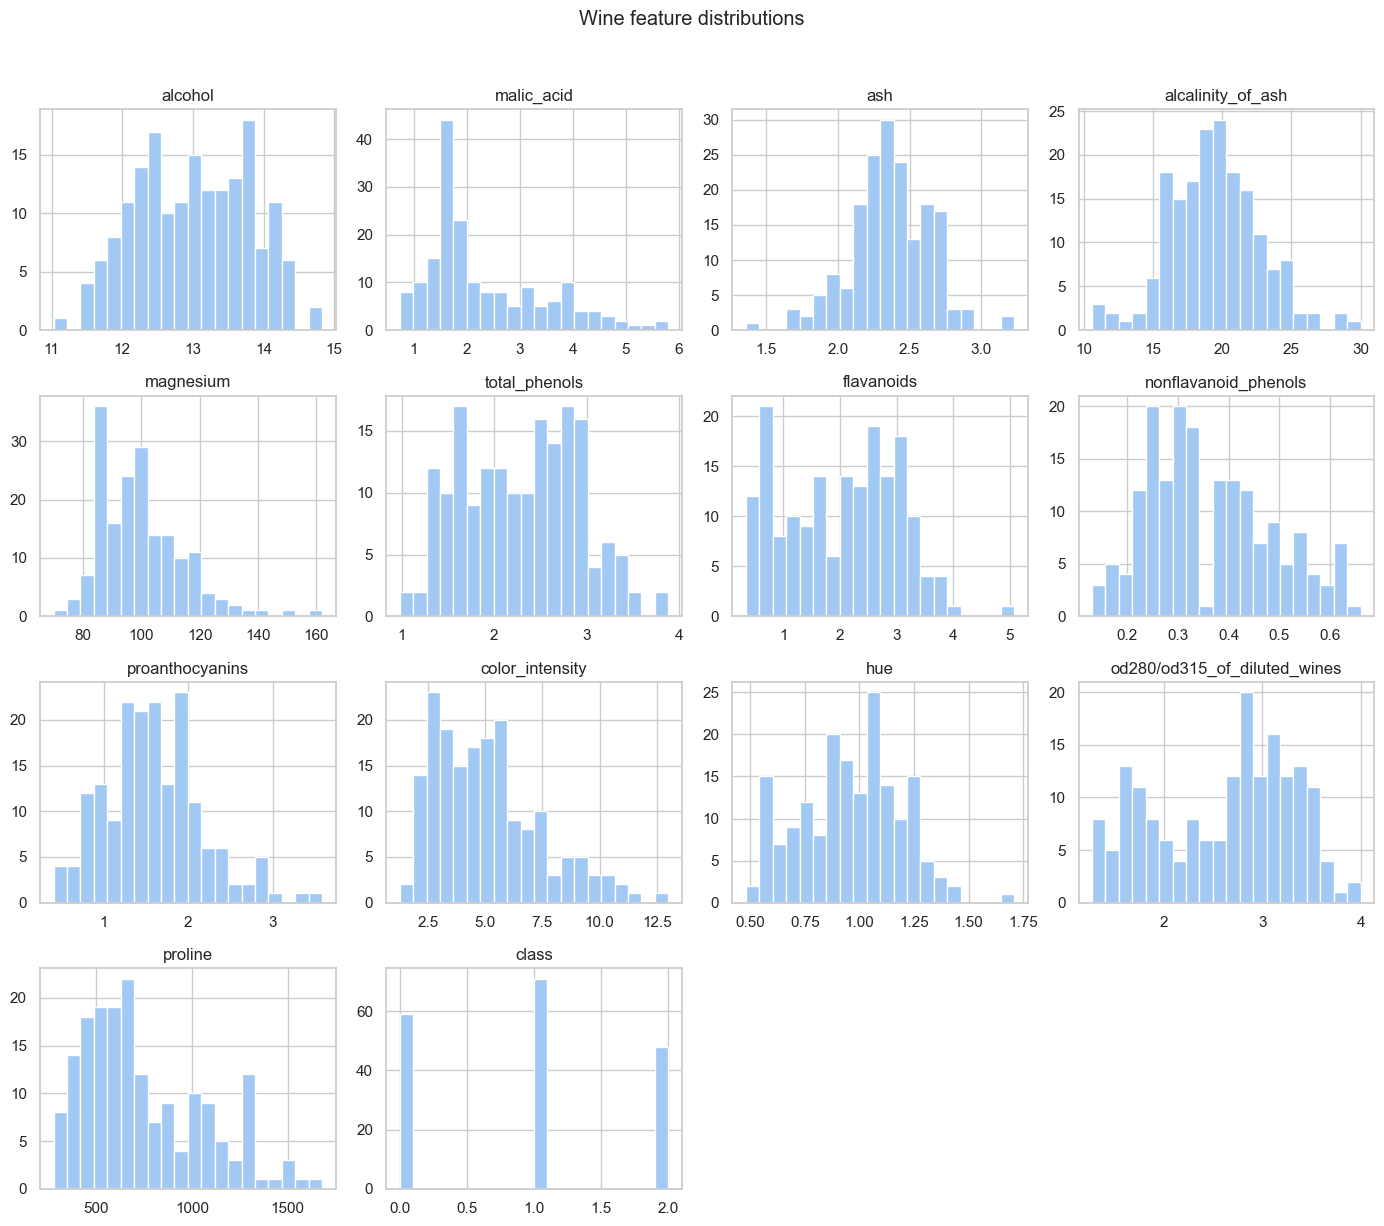

class
0    59
1    71
2    48
Name: count, dtype: int64
Class shares:
class
0    0.331
1    0.399
2    0.270
Name: count, dtype: float64


In [16]:
wine.hist(figsize=(14, 12), bins=20, edgecolor='white')
plt.suptitle('Wine feature distributions', y=1.02)
plt.tight_layout()
plt.show()

class_counts = wine['class'].value_counts().sort_index()
print(class_counts)
print('Class shares:')
print((class_counts / class_counts.sum()).round(3))

Most visible feature separating classes 0 and 2: proline


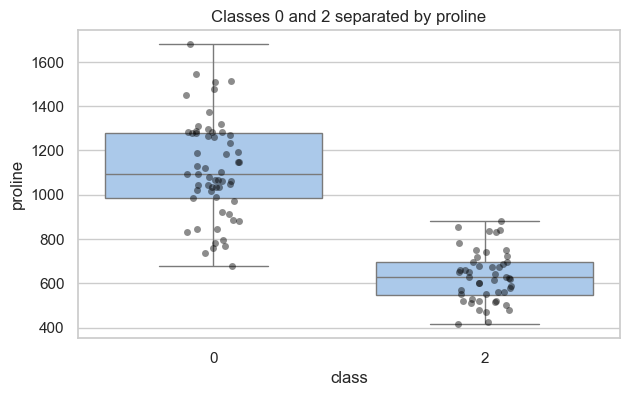

In [17]:
wine_0_2 = wine.loc[wine['class'].isin([0, 2])].copy()

feature_gap = (
    wine_0_2
    .groupby('class')
    .mean(numeric_only=True)
    .diff()
    .abs()
    .loc[2]
    .drop('class', errors='ignore')
    .sort_values(ascending=False)
)

best_feature = feature_gap.index[0]
print('Most visible feature separating classes 0 and 2:', best_feature)
feature_gap.head()

plt.figure(figsize=(7, 4))
sns.boxplot(data=wine_0_2, x='class', y=best_feature)
sns.stripplot(data=wine_0_2, x='class', y=best_feature, color='black', alpha=0.45)
plt.title(f'Classes 0 and 2 separated by {best_feature}')
plt.show()